# B19a · Predictive distributions, calibration and proper scores

<p class="subtitle">Research bridge · Core ★ · One win: distinguish a good mean from a good predictive distribution</p>

[B19](https://avistian.github.io/relational/lessons/b19-benchmark-evidence.html) asked whether two results describe comparable experiments. Even after aligning their data, splits and model versions, one question remains: **what counts as a good prediction?** A model predicting demand of 100 units can mean “almost certainly near 100” or “zero or 200 with equal probability.” The same mean can lead to different stocking decisions.

Our relational-learning mission needs both honest comparisons and useful predictions. This lesson adds a metric-and-calibration contract to your B23 reproduction plan. Work through the short trace first; use the notebook and primary paper for the longer lab.

[Student notebook](https://avistian.github.io/relational/labs/b19a-predictive-distributions.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/b19a-predictive-distributions.html) · [Solution notebook](https://avistian.github.io/relational/labs/solutions/b19a-predictive-distributions.ipynb) · [Printable reference](https://avistian.github.io/relational/reference/b19a-predictive-distributions.html) · [Reproduction contract](https://avistian.github.io/relational/labs/b19a-reproduction.md)



Prerequisites: expectation, probability mass, squared error, train/test separation; recall earlier calibration and conformal-prediction work. A **CDF**, F(z), is the probability that an outcome is at most z. A **quantile**, Q(q), is the smallest z with F(z) ≥ q. For a discrete distribution, its CDF jumps and nominal interval coverage need not be exact.





**Squared loss targets the conditional mean.** RMSE takes the square root after averaging squared errors. It cannot distinguish forecasts that share a mean. A **proper scoring rule** rewards the true predictive distribution in expectation; strict propriety makes it the unique optimum over the stated distribution class. This is a population statement, not a promise that the true distribution wins on every individual outcome. [ScoringBench §3 and Appendix A](https://arxiv.org/html/2603.29928v3#S3) · [Distributional regression study](https://arxiv.org/html/2603.08206v1)

<figure class="evidence-figure" tabindex="0" role="region" aria-label="Distribution-to-score computation and its calibration boundary.">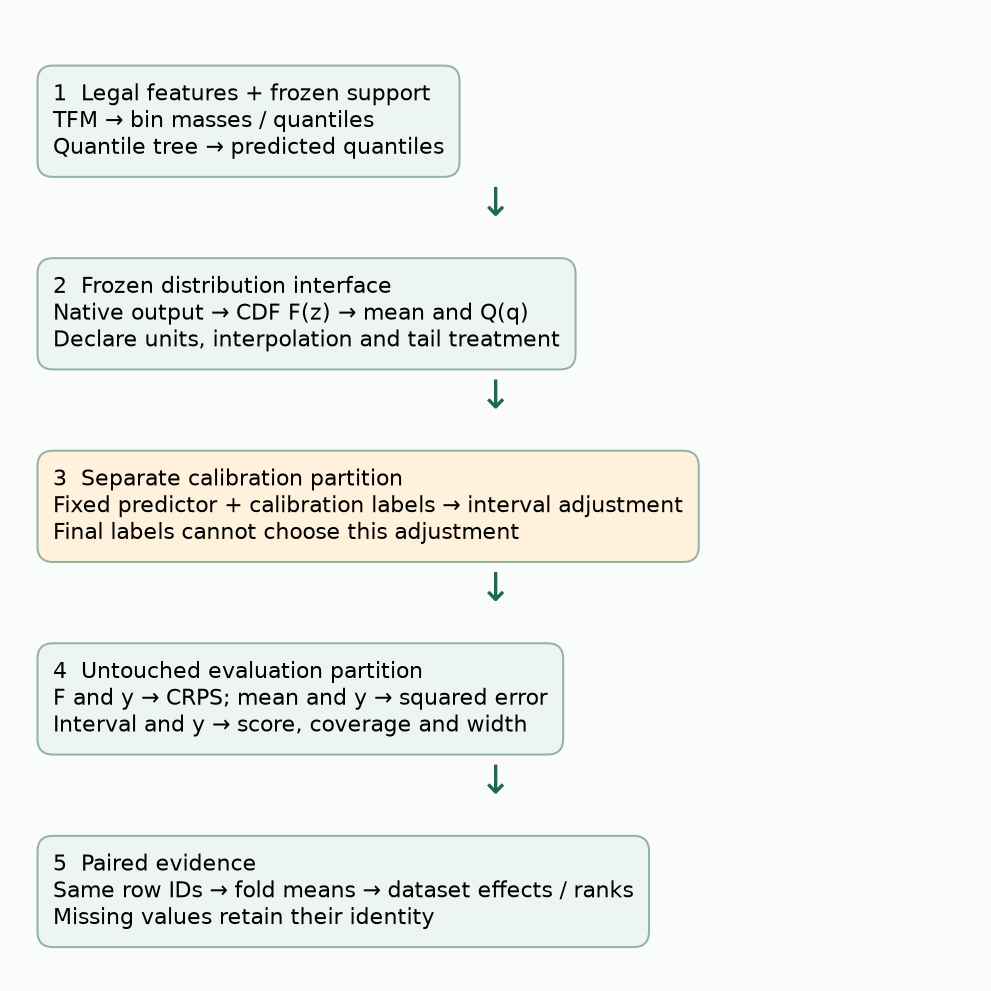<figcaption>Distribution-to-score computation and its calibration boundary. On narrow screens, scroll horizontally.</figcaption></figure>

This is an evaluation architecture, not a new neural network. A TFM's probability bins or quantiles and a tree's quantiles are different output representations. Their wrappers must define how to obtain a common CDF and quantiles, including interpolation and tails, before a fair score comparison is possible. Changing the wrapper can change the score without changing the mean.

## 2 · One mean, three distributions

Our complete finite experiment uses these forecasts, all with mean zero:

- **Narrow:** equal mass at −1 and +1.
- **Calibrated:** mass ¼, ½, ¼ at −2, 0, +2; this is also our declared true distribution.
- **Wide:** equal mass at −4 and +4.

The word calibrated here refers to equality with this known toy truth; it does not assert that a trained model is calibrated. We evaluate every possible outcome, weighted by its true probability, so this experiment has no Monte Carlo error.

**CRPS** measures the distance between a forecast CDF and the observed step CDF. For independent draws X and X′ from a finite forecast:

`CRPS(F,y) = E|X−y| − ½ E|X−X′|`.

The first term rewards proximity to the observation. The second prevents a distributional forecast from being judged only by average absolute distance to y. It does not make unlimited spread desirable: both terms change together.

**Hand trace at y=0:** the narrow forecast has E|X|=1. Two independent draws differ by 2 half the time, so E|X−X′|=1. CRPS is **1−½=0.5**. For the calibrated forecast, the terms are 1 and 1.5, giving **0.25**. For a point mass, the second term vanishes and CRPS becomes absolute error. CRPS has the target's units; 10× larger measurement units produce 10× larger CRPS.

<figure class="evidence-figure" tabindex="0" role="region" aria-label="Three forecast CDFs share mean zero; the observed CDF jumps at y=0.">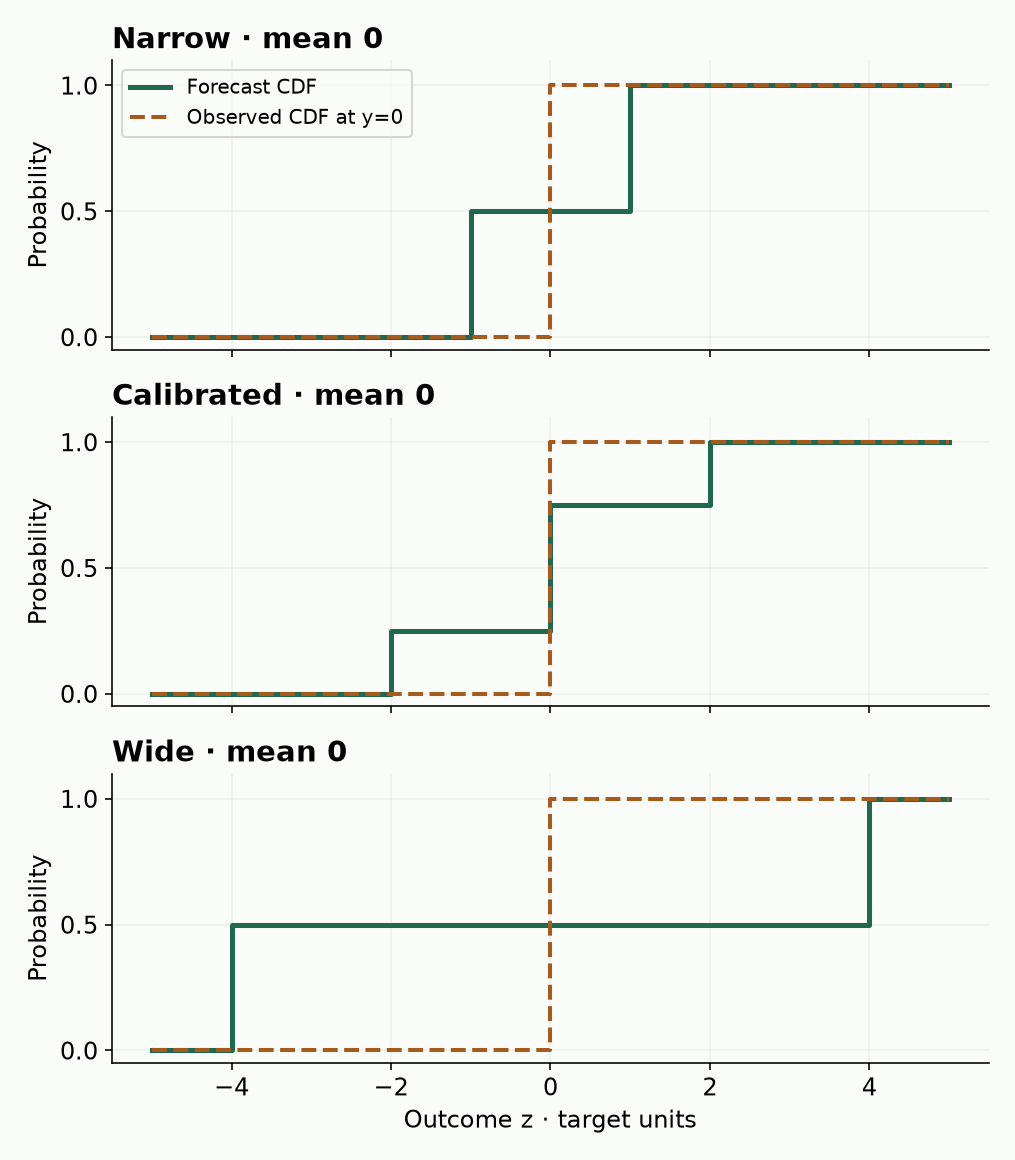<figcaption>Three forecast CDFs share mean zero; the observed CDF jumps at y=0. On narrow screens, scroll horizontally.</figcaption></figure>

**Predict first:** calculate the narrow forecast at y=0, then vary the notebook inputs.

At y=0, a point forecast at zero has CRPS 0, beating the true distribution’s 0.25 on that single observation. But it scores 2 at each extreme, so its truth-weighted expected CRPS is 1, worse than 0.75. This does not contradict strict propriety: the statement concerns the expectation over the true outcome distribution. The lab enumerates all 15 mass triples in increments of ¼ on {−2,0,2}; the true masses uniquely minimize expected CRPS in that finite family. This enumeration illustrates the theorem rather than proving it for every distribution.

## 3 · Coverage needs a width penalty

For a central (1−α) interval [l,u], lower interval score is better:

`ISα = (u−l) + (2/α)(l−y)·1[y<l] + (2/α)(y−u)·1[y>u]`.

The first term penalizes width. The other terms penalize misses. With α=0.2, interval [−1,1] and outcome 2: width=2, miss distance=1, multiplier=10, so **IS=12**. If the observation falls inside, only width is charged. This score elicits the interval's two quantiles, not the entire predictive distribution. Two different distributions can therefore tie on interval score. [ScoringBench Appendix A](https://arxiv.org/html/2603.29928v3#A1)



| Forecast | RMSE ↓ | Expected CRPS ↓ | Expected interval score ↓ | Coverage | Width ↓ |
|---|---:|---:|---:|---:|---:|
| Narrow | 1.4142 | 1.00 | 4.00 | 50% | 2 |
| Calibrated | 1.4142 | 0.75 | 4.00 | 75% | 2 |
| Wide | 1.4142 | 2.00 | 8.00 | 100% | 8 |


These are exact truth-weighted results, not sample estimates. Our 50% intervals use Q(.25) and Q(.75), with closed endpoints. For the calibrated discrete forecast the interval is [−2,0], which covers 75% of the truth; its jumps explain the excess over 50%. The narrow interval is [−1,1], and the wide interval [−4,4]. Narrow and calibrated forecasts tie on expected interval score although their CRPS differs.

**Coverage** measures how often y lies inside the interval. **Sharpness** describes concentration, here interval width. Narrow intervals can miss; very wide intervals can be useless. Evaluate both with an appropriate score. A proper distribution score, calibration diagnostic and point error answer different questions.

<figure class="evidence-figure" tabindex="0" role="region" aria-label="Exact finite expectation: CRPS distinguishes equal means; coverage alone rewards width.">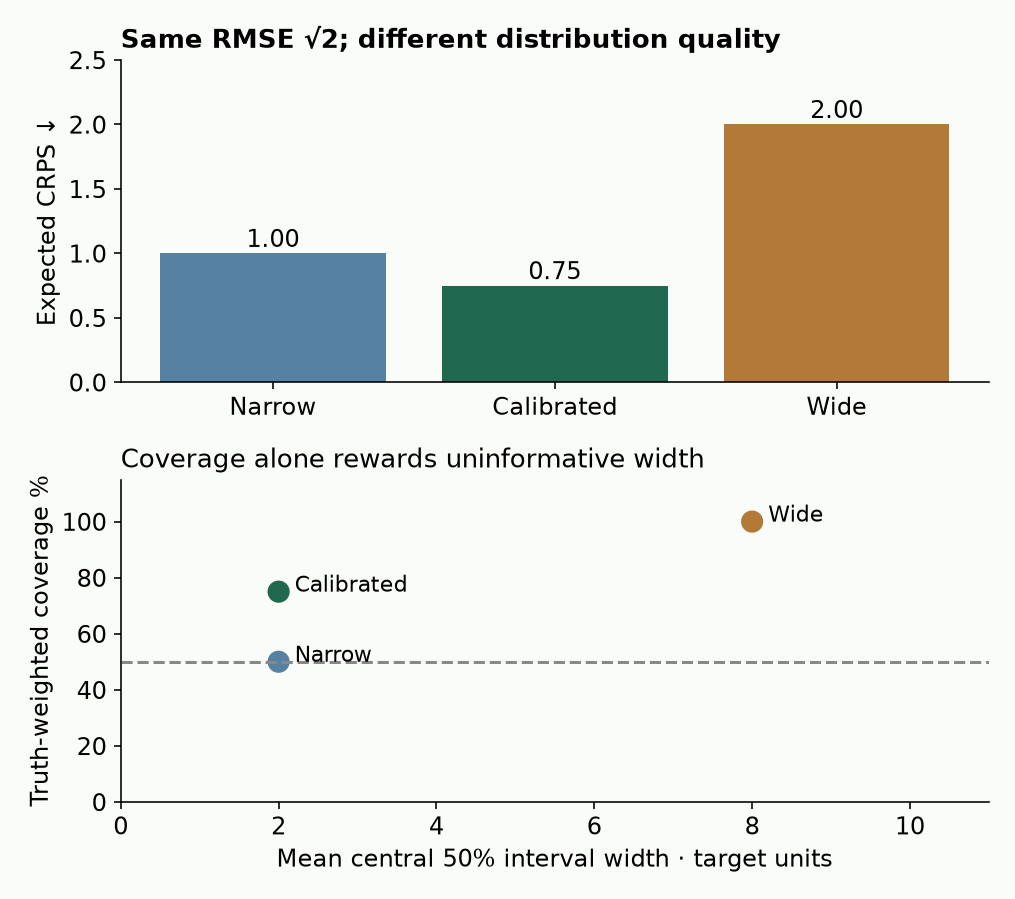<figcaption>Exact finite expectation: CRPS distinguishes equal means; coverage alone rewards width. On narrow screens, scroll horizontally.</figcaption></figure>

## 4 · Calibration has its own information boundary

An interval can be adjusted after fitting. In a simple split-conformal construction, freeze the mean predictor before calibration, compute absolute calibration residuals, and take order statistic k=ceil((n+1)(1−α)). With nine residuals 0,1,…,8 and α=.2, k=8 and the radius is 7. Predict [mean−7,mean+7]. If k>n, the finite-sample convention uses infinite radius; silently choosing the largest residual changes the procedure.

Keep the calibration labels separate from model selection and final evaluation. Our four final outcomes 0,7,8,20 yield coverage 2/4. Adding 100 to all final labels changes coverage to 0/4 but cannot change the fitted radius. That is the notebook's information-boundary test.

**Intervention:** change only final labels and verify that the calibrated radius stays fixed.

This deterministic fixture illustrates computation, not a guarantee. The split-conformal marginal coverage theorem requires exchangeability of calibration and the next test residual, with the predictor fitted independently of their labels. It does not promise the nominal fraction on every small test set, coverage within every customer subgroup, or protection under arbitrary temporal shift. Grouped relational rows require particular care; ordinary row-wise exchangeability cannot simply be assumed. [Angelopoulos and Bates, conformal introduction](https://arxiv.org/abs/2107.07511)

## 5 · Read the reproduced tables with the right claim

**Primary reading:** [ScoringBench v3 §3, Appendix A and protocol](https://arxiv.org/html/2603.29928v3). Read the [distributional regression study](https://arxiv.org/html/2603.08206v1) next for score-dependent training. Keep CRLS, which scores a CDF logarithmically, distinct from a log density score and from CRPS. Our discrete-atom lab deliberately implements CRPS and interval score; density scoring would need a different representation.

We recovered the historical release's complete 38-model roster and recomputed Tables 1, 4 and 5 from all 18,480 selected fold records. The release policy retains 97 common datasets after its coverage filter. All **798 displayed fields match at printed precision**, including mean rank, median, MAD, confidence endpoints, effect size and magnitude. Full-precision released leaderboard fields match too. [Code snapshot](https://github.com/jonaslandsgesell/ScoringBench/tree/ca1660023ba43dde460dbadb389b71e274e66ce1) · [Output snapshot](https://github.com/jonaslandsgesell/ScoringBenchOutput/tree/1cc77f6c79f2c88ef206f4b79f81c67861576ce6) · [Our complete reconstruction](https://avistian.github.io/relational/labs/evidence/b19a/reproduction.json)

| Target | Models × datasets | Published fields matched | Leading mean rank |
|---|---:|---:|---|
| CRPS | 38 × 97 | 266 / 266 | finetune_tabpfn_realv2_5_crls: 9.731959 |
| R2 | 38 × 97 | 266 / 266 | finetune_tabiclv2: 10.237113 |
| CRLS | 38 × 97 | 266 / 266 | finetune_tabiclv2: 6.103093 |


The leading mean rank changes between CRPS and CRLS; that is not evidence for a universal winner. The lab preserves every model and dataset effect, rather than selecting the score on which a preferred model wins. Raw scores may have different units across datasets; their cross-dataset median is not an application-wide error cost. Folds are averaged within each dataset before ranking.

**Protocol audit:** the paper says stratified folds, but the historical runner uses shuffled KFold. Its loader imputes the full feature table before splitting, exposing test feature statistics. The prose's approximate leading CRPS rank also differs from the actual table. We preserve these discrepancies in the [contract](https://avistian.github.io/relational/labs/b19a-reproduction.md). Table reconstruction measures numerical agreement, not protocol validity, model quality, or the magnitude of any leakage effect.

The portable notebook reconstructs all mean ranks and medians from an embedded saved-score packet. The repository additionally authenticates the original Parquet extraction and recalculates the full table statistics. Neither operation runs a model or rescores its raw predictive distributions. Fresh fits, pretraining and whole-paper reproduction remain **NOT_RUN**.



## Run contract

Self-contained Python standard library; no downloads, installs, credentials or repository imports. Embedded figures are author reference measurements. Code below performs a fresh finite diagnostic and replays saved author scores. It never trains a benchmark model. Live Colab frontend NOT_CHECKED. Optional lesson hyperlinks become live only after publication; core execution is offline.

In [ ]:
# @colab-bootstrap
import math,itertools,json,unittest,base64,gzip,hashlib
from pathlib import Path

## PROVIDED · hand-computable tests

Run a CHECK after each implementation. The full experiment calls all three learner functions.

In [ ]:
class ScoringTests(unittest.TestCase):
    def test_crps(self):
        self.assertAlmostEqual(crps([-1,1],[.5,.5],0),.5)
        self.assertAlmostEqual(crps([-2,0,2],[.25,.5,.25],0),.25)
        self.assertAlmostEqual(crps([3],[1],-2),5)
        self.assertAlmostEqual(crps([1,-1],[.5,.5],0),.5)
        self.assertAlmostEqual(crps([-2,2],[.5,.5],0),1)
        for v,p,y in [([],[],0),([0],[.9],0),([0,1],[1.1,-.1],0),([0],[1],float('nan')),([float('inf')],[1],0),([0,1],[1],0)]:
            with self.assertRaises(ValueError):crps(v,p,y)
    def test_interval(self):
        self.assertEqual(interval_score(-1,1,2,.2),12)
        self.assertEqual(interval_score(-1,1,-2,.2),12)
        self.assertEqual(interval_score(-1,1,0,.2),2)
        self.assertEqual(interval_score(-1,1,1,.2),2)
        for args in [(1,-1,0,.2),(-1,1,0,0),(-1,1,0,1),(-1,1,float('nan'),.2)]:
            with self.assertRaises(ValueError):interval_score(*args)
    def test_calibration(self):
        rows=[{'id':f'c{i}','split':'calibration','y':i,'mean':0} for i in range(9)]
        r=calibrate(rows,.2)
        self.assertEqual(r,{'n':9,'k':8,'radius':7.0,'ids':[f'c{i}' for i in range(9)]})
        self.assertEqual(calibrate(rows,.01)['radius'],float('inf'))
        for bad in [[],rows+[rows[0]],[dict(rows[0],split='test')],[dict(rows[0],y=float('nan'))]]:
            with self.assertRaises(ValueError):calibrate(bad,.2)
        for alpha in [0,1,float('nan')]:
            with self.assertRaises(ValueError):calibrate(rows,alpha)


## TODO · crps

Validate finite support and nonnegative unit mass; use the two expectation terms. Do not sample or call a hidden scoring library.

In [ ]:
def crps(values, probabilities, y):
    raise NotImplementedError("Implement crps")

### CHECK

In [ ]:
ScoringTests('test_crps').debug()
print('crps: passed')

## TODO · interval_score

Validate ordered endpoints and 0<alpha<1; implement width plus both outside-distance penalties.

In [ ]:
def interval_score(lower, upper, y, alpha):
    raise NotImplementedError("Implement interval_score")

### CHECK

In [ ]:
ScoringTests('test_interval').debug()
print('interval_score: passed')

## TODO · calibrate

Accept unique calibration IDs only. Compute the finite-sample residual order statistic. Reject test records; handle k>n as infinity.

In [ ]:
def calibrate(calibration_rows, alpha):
    raise NotImplementedError("Implement calibrate")

### CHECK

In [ ]:
ScoringTests('test_calibration').debug()
print('calibrate: passed')

## PROVIDED · quantiles and complete finite experiment

Read the data flow: quantiles come from the left inverse CDF; calibration receives no final test labels. All 9 forecast/outcome pairs, 15 probability triples and 18 affine interventions are retained.

In [ ]:
def quantile(values, probabilities, q):
    """Left generalized inverse; use stated endpoints for q=0 and q=1."""
    crps(values,probabilities,0)
    if not math.isfinite(q) or not 0<=q<=1:raise ValueError('Invalid quantile')
    mass=0
    for value,p in sorted(zip(values,probabilities)):
        mass+=p
        if mass>=q:return value
    return max(values)

In [ ]:
def run_experiment():
    truth=[(-2,.25),(0,.5),(2,.25)]
    forecasts={'narrow':([-1,1],[.5,.5]),'calibrated':([-2,0,2],[.25,.5,.25]),'wide':([-4,4],[.5,.5])}
    rows=[];summary=[]
    for name,(values,probabilities) in forecasts.items():
        mean=sum(x*p for x,p in zip(values,probabilities));lo=quantile(values,probabilities,.25);hi=quantile(values,probabilities,.75)
        local=[]
        for y,w in truth:
            r=dict(forecast=name,y=y,weight=w,mean=mean,lower=lo,upper=hi,squared_error=(y-mean)**2,crps=crps(values,probabilities,y),interval_score=interval_score(lo,hi,y,.5),covered=lo<=y<=hi,width=hi-lo)
            local.append(r);rows.append(r)
        summary.append(dict(forecast=name,mean=mean,rmse=math.sqrt(sum(r['weight']*r['squared_error'] for r in local)),**{k:sum(r['weight']*r[k] for r in local) for k in ['crps','interval_score','covered','width']}))
    grid=[]
    for a in range(5):
        for b in range(5-a):
            p=[a/4,b/4,(4-a-b)/4]
            grid.append(dict(probabilities=p,expected_crps=sum(w*crps([-2,0,2],p,y) for y,w in truth)))
    cal=[dict(id=f'c{i}',split='calibration',y=i,mean=0) for i in range(9)]
    fitted=calibrate(cal,.2);test=[dict(id=f't{i}',split='test',y=y,mean=0) for i,y in enumerate([0,7,8,20])]
    assert not set(fitted['ids'])&{r['id'] for r in test}
    before=fitted.copy();changed=[dict(r,y=r['y']+100) for r in test]
    after=calibrate(cal,.2)
    interventions=[]
    for r in rows:
        v,p=forecasts[r['forecast']]
        for scale,shift in [(1,7),(10,-3)]:
            interventions.append(dict(forecast=r['forecast'],y=r['y'],scale=scale,shift=shift,crps_scaled=crps([scale*x+shift for x in v],p,scale*r['y']+shift),expected=scale*r['crps'],interval_scaled=interval_score(scale*r['lower']+shift,scale*r['upper']+shift,scale*r['y']+shift,.5),interval_expected=scale*r['interval_score']))
    return dict(protocol='B19a-SAME-MEAN',forecasts={k:dict(values=v,probabilities=p) for k,(v,p) in forecasts.items()},truth=truth,rows=rows,summary=summary,propriety_grid=grid,unit_interventions=interventions,calibration=dict(fitted=fitted,test=test,changed_test=changed,radius_unchanged=before==after,coverage=sum(abs(r['y'])<=fitted['radius'] for r in test)/len(test),shifted_coverage=sum(abs(r['y'])<=fitted['radius'] for r in changed)/len(changed)),paper_training='NOT_RUN')

In [ ]:
report=run_experiment()
Path('b19a-diagnostic.json').write_text(json.dumps(report,indent=2,allow_nan=False)+'\n')
for row in report['summary']: print(row)
assert len(report['propriety_grid'])==15
assert all(x['crps_scaled']==x['expected'] and x['interval_scaled']==x['interval_expected'] for x in report['unit_interventions'])
assert report['calibration']['radius_unchanged']
print('Calibration:',report['calibration'])

## Replay · complete saved fold scores

18,480 rows from 38 historical model tables. Packet hash establishes embedded-byte identity; repository verification independently compares every row with authenticated original Parquet bytes. Missing values are None. Portable replay recomputes all mean ranks and medians, not the autorank confidence/effect columns. No raw predictions or fresh model fits are available here.

In [ ]:
packet=base64.b64decode('...')
assert hashlib.sha256(packet).hexdigest()=='01f06b28e6e915e03af5c6e5f96d072865d01279a1423e03bb1272ec5657bb6b'
records=json.loads(gzip.decompress(packet))
assert len(records)==18480

In [ ]:
def replay(records):
    """Portable mean-rank/median reconstruction from ALL released selected scores.

Rows: [dataset, model, fold, crps, r2, crls]. None denotes missing, never zero.
Same release policy: model coverage>=90%, then complete dataset intersection.
"""
    from collections import defaultdict
    import statistics
    keys=set();groups=defaultdict(list);datasets=set();models=set()
    for row in records:
        if len(row)!=6:raise ValueError('Invalid row width')
        d,m,f,*scores=row
        if not isinstance(d,str) or not isinstance(m,str) or f not in range(5) or (d,m,f) in keys:raise ValueError('Duplicate or invalid score key')
        if any(x is not None and not math.isfinite(x) for x in scores):raise ValueError('Nonfinite score')
        keys.add((d,m,f));datasets.add(d);models.add(m);groups[d,m].append(row)
    for key,rows in groups.items():
        if {r[2] for r in rows}!=set(range(5)):raise ValueError('Incomplete folds: '+str(key))
    output={}
    for j,metric in enumerate(['crps','r2','crls'],3):
        means={key:statistics.mean(r[j] for r in rows if r[j] is not None) for key,rows in groups.items() if any(r[j] is not None for r in rows)}
        included=sorted(m for m in models if sum((d,m) in means for d in datasets)>=.9*len(datasets))
        support=sorted(d for d in datasets if all((d,m) in means for m in included))
        if not included or not support:raise ValueError('Empty comparable support')
        stats=[]
        for m in included:
            ranks=[]
            for d in support:
                v=means[d,m];others=[means[d,x] for x in included]
                better=sum(x>v if metric=='r2' else x<v for x in others);ties=sum(x==v for x in others)
                ranks.append(1+better+(ties-1)/2)
            stats.append(dict(model=m,meanrank=statistics.mean(ranks),median=statistics.median(means[d,m] for d in support)))
        output[metric]=dict(datasets=support,dropped_datasets=sorted(datasets-set(support)),models=included,rows=sorted(stats,key=lambda x:(x['meanrank'],x['model'])))
    return output

In [ ]:
ranking=replay(records)
Path('b19a-replay.json').write_text(json.dumps(ranking,indent=2)+'\n')
for metric,data in ranking.items():
    assert len(data['models'])==38 and len(data['datasets'])==97
    print(metric, data['rows'][:2], 'Dropped:',data['dropped_datasets'])

## Paired dataset effects · inspect before ranking

Compare released TabICLv2 and quantile CatBoost on the same 97 datasets. Negative CRPS difference favors TabICLv2. Units differ across datasets: retain each raw effect rather than treating their mean as an application cost. These are saved results; this comparison is not the new contract you will preregister.

In [ ]:
from collections import defaultdict
paired=defaultdict(dict)
for dataset,model,fold,c,r2,l in records:
    if dataset in ranking['crps']['datasets'] and model in ['tabiclv2','catboost_quantile']:
        paired[dataset].setdefault(model,[]).append(c)
effects=[{'dataset':d,'tabiclv2_minus_catboost_crps':sum(v['tabiclv2'])/5-sum(v['catboost_quantile'])/5} for d,v in sorted(paired.items())]
assert len(effects)==97
Path('b19a-paired-effects.json').write_text(json.dumps(effects,indent=2)+'\n')
for row in effects: print(row)

## EXIT · freeze a new metric-and-calibration contract

Specify a paired version-pinned TFM and probabilistic/quantile tree, accessible inputs, untouched evaluation IDs, separate tuning/calibration data, equal tuning budgets, primary score, RMSE/CRPS/interval diagnostics, quantile extraction/tails, units, dataset effects, missing-run policy and total cost cap. State exchangeability assumptions and what would falsify your thesis. Explain why all 798 published table fields matching does not establish fresh training. Ask the teacher for review; revisit after 1/7/30 days. Learner PENDING_WRITTEN_DEFENSE.